<a href="https://colab.research.google.com/github/iestleija/4808-Programacion/blob/Unidad3/4808_P01_Sem14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Maestría en Inteligencia Artificial y Analítica de Datos**

- Curso: Programación para Analítica Descriptiva y Predictiva

- Semestre: Enero-Junio

- Profesor: Dr. Vicente García Jiménez
- Semana 14. Práctica: Ejercicios sobre Clases No Balanceadas, Data Leakage (Pipeline) y SVM
- Alumno: Ismael Estrada Leija
- Matrícula: 266229

# Instrucciones
La presente tarea tiene como objetivo aplicar técnicas de aprendizaje automático para el tratamiento de clases no balanceadas utilizando un problema de clasificación real.

Para el desarrollo de la actividad deberán utilizar el conjunto de datos:
compustat.csv

**Consideraciones importantes:**
- El conjunto de datos contiene 21 atributos.
- El primer atributo corresponde a un índice, por lo que deberá ser ignorado durante el análisis y entrenamiento.
- El último atributo corresponde a la etiqueta de clase.
- Los atributos restantes deberán utilizarse como variables predictoras.
La solución deberá desarrollarse en un cuaderno de Google Colab o Jupyter Notebook almacenado en GitHub. La entrega consistirá en compartir la liga pública del notebook para su revisión.


In [118]:
from google.colab import drive
drive.mount('/content/drive')

def print_bold(msg):
    print("\n\033[1m" + msg + "\033[0m")

path_to_file='/content/drive/MyDrive/4808-programacion/semana14/compustat.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##1.Análisis Exploratorio de Datos (AED)
---
>Para esta actividad revisa el Notebook que està en Teams en la Sesión 27 y que se llama DataLeakage_ClassImbalance.ipynb

Realizar:
- Un diagrama de barras mostrando la distribución de las clases.
- Diagramas de densidad KDE para los atributos 5 y 13.
- Un análisis breve sobre el nivel de desbalance presente en el conjunto de datos.



In [119]:
import pandas as pd

# Cargar el conjunto de datos
df = pd.read_csv(path_to_file);

##Estructura del Conjunto de Datos
---
Se comprueba que el conjunto de datos contiene 21 atributos de los cuales la columna `idx` deberá ser retirada y la columna `label` corresponde a la variable  objetivo.

In [120]:
print_bold('DataFrame Info:')
df.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13657 entries, 0 to 13656
Data columns (total 22 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   idx     13657 non-null  int64  
 1   at0     13657 non-null  float64
 2   at1     13657 non-null  float64
 3   at2     13657 non-null  float64
 4   at3     13657 non-null  float64
 5   at4     13657 non-null  float64
 6   at5     13657 non-null  float64
 7   at6     13657 non-null  float64
 8   at7     13657 non-null  float64
 9   at8     13657 non-null  float64
 10  at9     13657 non-null  float64
 11  at10    13657 non-null  float64
 12  at11    13657 non-null  float64
 13  at12    13657 non-null  float64
 14  at13    13657 non-null  float64
 15  at14    13657 non-null  float64
 16  at15    13657 non-null  float64
 17  at16    13657 non-null  float64
 18  at17    13657 non-null  float64
 19  at18    13657 non-null  float64
 20  at19    13657 non-null  float64
 21  label   13657 non-

In [121]:
# Identify the target variable (last column)
target_column_name = df.columns[-1]

# Drop the 'idx' column as it's an index and not a predictor
if 'idx' in df.columns:
    df = df.drop(columns=['idx'])

# Identify predictors labels AFTER 'idx' has been dropped
predictors_labels = df.columns.drop(target_column_name)

### Diagrama de Barras para la Variable `label`
La gráfica es elocuente mostrando el desbalance de clases, por su dispar cantidad de incidencia en el conjunto de datos, siendo de 13137 muestras para 0 y apenas 520 para 1. De aqui que la relación resultó en 25.3 casos de `Clase 0` por cada caso de la `Clase 1`
Se trata de un desbalance de clases donde a grandes rasgos tenemos una incidencia de 96%/4%.


Distribución de clases para la variable objetivo: label
label
0    13137
1      520
Name: count, dtype: int64

Estamos ante un caso de variable categórica desbalanceada

La clase minoritaria representa apenas el 3.96%


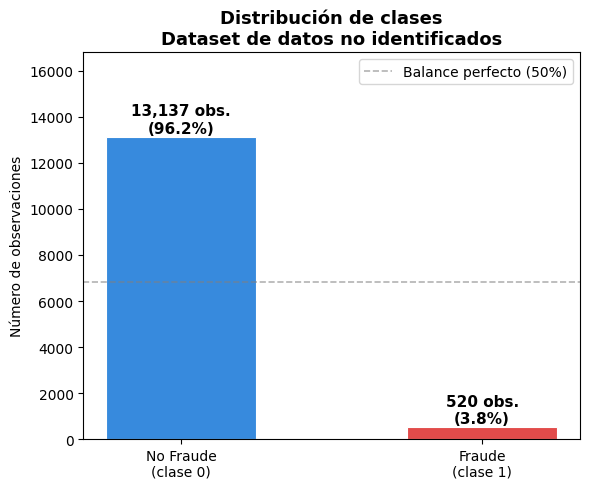

Ratio mayoritaria / minoritaria : 25.3:1
Un clasificador trivial que prediga siempre 'No Fraude'
obtendría 96.2% de accuracy sin aprender nada.


In [122]:
# ── Gráfica 1: Distribución de clases ────────────────────────────
# Visualiza la asimetría numérica entre clases de forma directa.
# Es el punto de partida obligatorio antes de cualquier modelado.

fig, ax = plt.subplots(figsize=(6, 5))

print_bold(f"Distribución de clases para la variable objetivo: {target_column_name}")
class_distribution = df['label'].value_counts()
print(class_distribution)
print_bold(f"Estamos ante un caso de variable categórica desbalanceada");
print_bold(f"La clase minoritaria representa apenas el {class_distribution[1] / class_distribution[0] * 100 :.2f}%")

PALETA  = {'No Fraude': '#378ADD', 'Fraude': '#E24B4A'}
COLORES = ['#378ADD', '#E24B4A']

n_may_count = class_distribution.max()
n_min_count = class_distribution.min()
n_total = class_distribution.sum()

# Gráfico de barras
conteo = [n_may_count, n_min_count]
barras = ax.bar(
    ['No Fraude\n(clase 0)', 'Fraude\n(clase 1)'],
    conteo,
    color    = COLORES,
    edgecolor= 'white',
    linewidth= 0.8,
    width    = 0.5
)

# Etiquetas sobre cada barra: valor absoluto y porcentaje
for barra, val in zip(barras, conteo):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 40,
        f'{val:,} obs.\n({val/n_total*100:.1f}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

# Línea de referencia: balance perfecto
ax.axhline(
    n_total / 2, color='gray', linestyle='--',
    linewidth=1.2, alpha=0.6, label='Balance perfecto (50%)'
)

ax.set_title('Distribución de clases\nDataset de datos no identificados',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Número de observaciones')
ax.set_ylim(0, n_may_count * 1.28)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('g1_distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Ratio mayoritaria / minoritaria : {n_may_count/n_min_count:.1f}:1")
print(f"Un clasificador trivial que prediga siempre 'No Fraude'")
print(f"obtendría {n_may_count/n_total*100:.1f}% de accuracy sin aprender nada.")

### Curvas KDE por Clase sobre los Atributos `at5` y `at13`
Estas gráficas muestran la densidad normalizada de las clases, sin importar su desbalance, dependiendo del valor del atributo (at5 y at13) en cada gráfica.
El solapamiento de las gráficas denota la ambigüedad que encuentra el modelo para decidir que clase predomina a partir del valor del atributo base.
Sin embargo, por encima de un valor de 1000 para ambos atributos es claro que se asocia la `Clase 0`

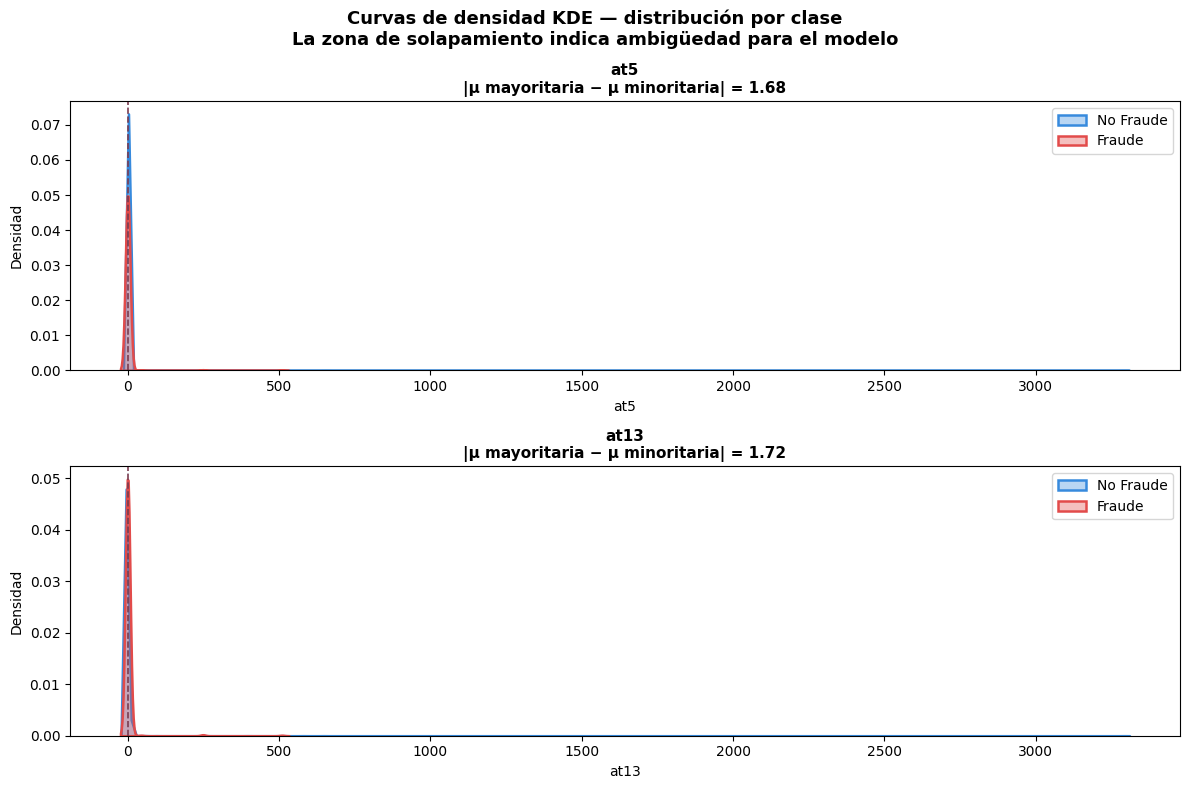

Separación entre medias por feature (mayor = más discriminativa):
──────────────────────────────────────────────────
  at9 : 2.614  ██████████████████████████
  at13 : 1.718  █████████████████
  at5 : 1.683  ████████████████
  at8 : 1.282  ████████████
  at1 : 0.881  ████████
  at18 : 0.794  ███████
  at14 : 0.364  ███
  at16 : 0.233  ██
  at7 : 0.197  █
  at2 : 0.150  █
  at10 : 0.069  
  at6 : 0.054  
  at15 : 0.037  
  at17 : 0.032  
  at19 : 0.028  
  at4 : 0.016  
  at0 : 0.015  
  at11 : 0.009  
  at12 : 0.005  
  at3 : 0.002  


In [123]:
# ── Gráfica 3: Curvas de densidad KDE por clase ───────────────────
# Compara la distribución de cada feature entre clases.
# Usamos las 2 features más informativas en una grilla 1x2
# para identificar cuáles tienen mayor poder discriminativo.
import seaborn as sns
import matplotlib.pyplot as plt

features_kde = ['at5', 'at13']

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes = axes.flatten()

# Map numerical labels to descriptive strings for legend
label_map = {0: 'No Fraude', 1: 'Fraude'}

for ax, feature in zip(axes, features_kde):
    for numeric_label in sorted(df['label'].unique()): # Iterate through 0 and 1
        string_label = label_map[numeric_label]
        color = PALETA[string_label]
        sns.kdeplot(
            df.loc[df['label'] == numeric_label, feature],
            ax        = ax,
            label     = string_label, # Use string_label for legend
            color     = color,
            fill      = True,
            alpha     = 0.35,
            linewidth = 1.8
        )

    # Calcular y anotar el solapamiento visual (diferencia de medias)
    media_may = df.loc[df['label'] == 0, feature].mean()
    media_min = df.loc[df['label'] == 1,    feature].mean()
    separacion = abs(media_may - media_min)

    ax.set_title(f'{feature}\n'
                 f'|μ mayoritaria − μ minoritaria| = {separacion:.2f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel(feature)
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=10)

    # Marcar las medias de cada clase con líneas verticales
    ax.axvline(media_may, color='#185FA5', linestyle='--',
               linewidth=1.2, alpha=0.7)
    ax.axvline(media_min, color='#A32D2D', linestyle='--',
               linewidth=1.2, alpha=0.7)

plt.suptitle('Curvas de densidad KDE — distribución por clase\n'
             'La zona de solapamiento indica ambigüedad para el modelo',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('g3_kde_clases.png', dpi=150, bbox_inches='tight')
plt.show()

# Resumen numérico del poder discriminativo por feature
print("Separación entre medias por feature (mayor = más discriminativa):")
print("─" * 50)
separaciones = {}
for feat in predictors_labels:
    m0 = df.loc[df['label'] == 0, feat].mean()
    m1 = df.loc[df['label'] == 1, feat].mean()
    separaciones[feat] = abs(m0 - m1)

for feat, sep in sorted(separaciones.items(), key=lambda x: -x[1]):
    barra = '█' * int(sep * 10)
    print(f"  {feat} : {sep:.3f}  {barra}")

###Desbalance en la Variable Objetivo
Como se ha observado antes nos encontramos ante una distribución altamente desbalanceada en la variable categórica objetivo. Una relación de 25:1 entre la `Clase 0` y la `Clase 1`, con porcentajes de incidencia de 96% y 4% respectivamente.

##2.Modelo Base
---
Entrenar un modelo baseline utilizando:
```python
Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale'))
])
```
Este modelo deberá entrenarse sin aplicar métodos de tratamiento de desbalance y servirá como referencia para comparar los resultados posteriores.


### 2.1. Preparación de Datos y División de Conjuntos

Antes de entrenar el modelo, se dividen los datos en conjuntos de entrenamiento y prueba. Esto es crucial para evaluar el rendimiento del modelo en datos no vistos.

In [124]:
# Prepare data for analysis: features (X) and target (y)

X = df[predictors_labels]  # Define X using the identified predictors labels
y = df[target_column_name]  # Define y as the target variable


In [125]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print_bold('Dimensiones de X_train:')
print(X_train.shape)
print_bold('Conteo de valores de y_train:')
print(y_train.value_counts())
print_bold('Dimensiones de X_test:')
print(X_test.shape)
print_bold('Conteo de valores de y_test:')
print(y_test.value_counts())


Dimensiones de X_train:
(10925, 20)

Conteo de valores de y_train:
label
0    10509
1      416
Name: count, dtype: int64

Dimensiones de X_test:
(2732, 20)

Conteo de valores de y_test:
label
0    2628
1     104
Name: count, dtype: int64


### 2.2. Definición y Entrenamiento del Modelo Base

Se crea el Pipeline con `StandardScaler` y `SVC` (Support Vector Classifier) y se entrena con los datos de entrenamiento. Este será nuestro modelo de referencia.

In [126]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Define the baseline model pipeline
baseline_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))
])

# Train the baseline model
print_bold('Entrenando el modelo base...')
baseline_model.fit(X_train, y_train)
print_bold('Entrenamiento del modelo base completado.')


Entrenando el modelo base...

Entrenamiento del modelo base completado.


##3.Tratamiento de Clases No Balanceadas
---
Aplicar y comparar los siguientes métodos:
- SMOTEENN
- One-Sided Selection

Para cada método:
- Mostrar la nueva distribución de clases después del balanceo.
- Entrenar nuevamente el modelo SVM utilizando los datos balanceados.


In [127]:
# Instalar imblearn si aún no está instalado
!pip install imblearn -q

### 3.1. Balanceo de Clases con SMOTEENN

SMOTEENN es un método híbrido que combina SMOTE (Synthetic Minority Over-sampling Technique) y Edited Nearest Neighbours (ENN). SMOTE genera nuevas muestras de la clase minoritaria, y ENN limpia el ruido eliminando muestras que son clasificadas erróneamente por sus vecinos a la vez que suaviza la frontera de decisión

In [128]:
from imblearn.combine import SMOTEENN
from collections import Counter

print_bold('Aplicando SMOTEENN...')

# Crear copias de los datos de entrenamiento para SMOTEENN
X_train_smoteenn, y_train_smoteenn = X_train.copy(), y_train.copy()

smoteenn = SMOTEENN(random_state=42)
X_train_smoteenn_resampled, y_train_smoteenn_resampled = smoteenn.fit_resample(X_train_smoteenn, y_train_smoteenn)

print_bold('Distribución de clases después de SMOTEENN:')
print(Counter(y_train_smoteenn_resampled))


Aplicando SMOTEENN...

Distribución de clases después de SMOTEENN:
Counter({1: 10434, 0: 9395})


#### 3.1.1. Entrenamiento del Modelo con SMOTEENN
Conforme a las indicaciones del correcto flujo de trabajo se realiza el entrenamiento del modelo despues de aplicar SMOTEENN

In [129]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Definir el pipeline con StandardScaler y SVC
pipeline_smoteenn = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))
])

print_bold('Entrenando el modelo con SMOTEENN...')
# Entrenar el modelo con los datos balanceados por SMOTEENN
pipeline_smoteenn.fit(X_train_smoteenn_resampled, y_train_smoteenn_resampled)
print_bold('Entrenamiento del modelo con SMOTEENN completado.')


Entrenando el modelo con SMOTEENN...

Entrenamiento del modelo con SMOTEENN completado.


### 3.2. Balanceo de Clases con One-Sided Selection (OSS)

One-Sided Selection es una técnica de submuestreo que selecciona una parte de las muestras de la clase mayoritaria. Utiliza Tomek Links y Condensed Nearest Neighbours para eliminar ejemplos redundantes y ruidosos de la clase mayoritaria, manteniendo la clase minoritaria intacta.

In [130]:
from imblearn.under_sampling import OneSidedSelection

print_bold('Aplicando One-Sided Selection...')

# Crear copias de los datos de entrenamiento para One-Sided Selection
X_train_oss, y_train_oss = X_train.copy(), y_train.copy()

oss = OneSidedSelection(random_state=42)
X_train_oss_resampled, y_train_oss_resampled = oss.fit_resample(X_train_oss, y_train_oss)

print_bold('Distribución de clases después de One-Sided Selection:')
print(Counter(y_train_oss_resampled))


Aplicando One-Sided Selection...

Distribución de clases después de One-Sided Selection:
Counter({0: 10222, 1: 416})


#### 3.2.1. Entrenamiento del Modelo con One-Sided Selection
Se realiza el entrenamiento del modelo sobre los datasets intervenidos con One Side Selection

In [131]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Definir el pipeline con StandardScaler y SVC para OSS
pipeline_oss = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))
])

print_bold('Entrenando el modelo con One-Sided Selection...')
# Entrenar el modelo con los datos balanceados por One-Sided Selection
pipeline_oss.fit(X_train_oss_resampled, y_train_oss_resampled)
print_bold('Entrenamiento del modelo con One-Sided Selection completado.')


Entrenando el modelo con One-Sided Selection...

Entrenamiento del modelo con One-Sided Selection completado.


##4.Entrenamiento y Evaluación del Modelo
---
- Utilizar validación cruzada estratificada de 5 particiones.
- Implementar el flujo de trabajo utilizando Pipeline para evitar data leakage.
- Incorporar escalado de datos dentro del Pipeline.
- Utilizar SVM con kernel RBF.


##4.Entrenamiento y Evaluación del Modelo
---
En esta sección, se procederá con el entrenamiento y evaluación exhaustiva de los modelos, aplicando las siguientes directrices para garantizar la robustez y comparabilidad de los resultados:

1.  **Utilizar validación cruzada estratificada de 5 particiones:** Se empleará `StratifiedKFold` para mantener la proporción de clases en cada partición, crucial para datasets desbalanceados.
2.  **Implementar el flujo de trabajo utilizando `Pipeline` para evitar data leakage:** Todas las transformaciones (escalado y re-muestreo) se integrarán en un `Pipeline` para asegurar que cada paso se aplique correctamente dentro de cada fold de validación cruzada, previniendo así la fuga de información.
3.  **Incorporar escalado de datos dentro del `Pipeline`:** Se utilizará `StandardScaler` para normalizar las características, lo cual es esencial para el buen desempeño de los algoritmos basados en distancia como SVM.
4.  **Utilizar SVM con kernel RBF:** El clasificador `SVC` con un kernel de función base radial (RBF) se empleará como el algoritmo de aprendizaje automático.


In [132]:
from imblearn.pipeline import Pipeline as ImbPipeline # Importamos Pipeline de imblearn
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# 1. Definir las métricas de evaluación
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0),
    'f1': make_scorer(f1_score, zero_division=0)
}

# 2. Configurar la validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


### 4.1. Evaluación del Modelo Base con Validación Cruzada

In [133]:
print_bold('Evaluando el Modelo Base (sin re-balanceo) con Validación Cruzada Estratificada...')

# Realizar validación cruzada en el modelo base
cv_results_baseline = cross_validate(baseline_model, # El baseline_model ya es un Pipeline con scaler y SVM
                                     X_train,
                                     y_train,
                                     cv=cv,
                                     scoring=scoring,
                                     return_train_score=False)

print_bold('Evaluación del Modelo Base completada.')



Evaluando el Modelo Base (sin re-balanceo) con Validación Cruzada Estratificada...

Evaluación del Modelo Base completada.


### 4.2. Evaluación del Modelo con SMOTEENN y Validación Cruzada

In [134]:
from imblearn.combine import SMOTEENN
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Definir el Pipeline que incluye el escalado, SMOTEENN y el SVM
# Es crucial que SMOTEENN esté dentro del ImbPipeline para que se aplique en cada fold de CV
pipeline_smoteenn_cv = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smoteenn', SMOTEENN(random_state=42)),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))
])

print_bold('Evaluando el Modelo con SMOTEENN con Validación Cruzada Estratificada...')

# Realizar validación cruzada en los datos ORIGINALES de entrenamiento
cv_results_smoteenn = cross_validate(pipeline_smoteenn_cv,
                                     X_train, # Usamos los datos originales X_train, y_train
                                     y_train, # El pipeline se encarga del re-muestreo internamente en cada fold
                                     cv=cv,
                                     scoring=scoring,
                                     return_train_score=False)

print_bold('Evaluación del Modelo con SMOTEENN completada.')



Evaluando el Modelo con SMOTEENN con Validación Cruzada Estratificada...

Evaluación del Modelo con SMOTEENN completada.


### 4.3. Evaluación del Modelo con One-Sided Selection y Validación Cruzada

In [135]:
from imblearn.under_sampling import OneSidedSelection
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Definir el Pipeline que incluye el escalado, One-Sided Selection y el SVM
pipeline_oss_cv = ImbPipeline([
    ('scaler', StandardScaler()),
    ('oss', OneSidedSelection(random_state=42)),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))
])

print_bold('Evaluando el Modelo con One-Sided Selection con Validación Cruzada Estratificada...')

# Realizar validación cruzada en los datos ORIGINALES de entrenamiento
cv_results_oss = cross_validate(pipeline_oss_cv,
                                X_train, # Usamos los datos originales X_train, y_train
                                y_train, # El pipeline se encarga del re-muestreo internamente en cada fold
                                cv=cv,
                                scoring=scoring,
                                return_train_score=False)

print_bold('Evaluación del Modelo con One-Sided Selection completada.')



Evaluando el Modelo con One-Sided Selection con Validación Cruzada Estratificada...

Evaluación del Modelo con One-Sided Selection completada.


##5.Evaluación de Resultados
---
Reportar y analizar al menos las siguientes métricas:
- Accuracy
- Precision
- Recall
- 1-score
- Matriz de confusión

Además:
- Comparar los resultados del modelo baseline contra los modelos balanceados.
- Generar una gráfica comparativa de métricas.
- Analizar si Accuracy es suficiente para evaluar el problema.


### 5.1. Comparación de Métricas de Cross-Validation

In [136]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Función para extraer y promediar las métricas de un diccionario de resultados de CV
def get_avg_metrics(cv_results, model_name):
    metrics = {}
    for metric_name, values in cv_results.items():
        if 'test_' in metric_name:
            clean_name = metric_name.replace('test_', '').capitalize()
            metrics[clean_name] = np.mean(values)
    df_metrics = pd.DataFrame([metrics], index=[model_name])
    return df_metrics

# Extraer métricas para cada modelo
df_baseline_metrics = get_avg_metrics(cv_results_baseline, 'Modelo Base')
df_smoteenn_metrics = get_avg_metrics(cv_results_smoteenn, 'SMOTEENN')
df_oss_metrics = get_avg_metrics(cv_results_oss, 'One-Sided Selection')

# Unir todos los DataFrames de métricas
df_all_metrics = pd.concat([df_baseline_metrics, df_smoteenn_metrics, df_oss_metrics])

print_bold('Métricas Promedio de Cross-Validation para todos los modelos:')
print(df_all_metrics.round(4))



Métricas Promedio de Cross-Validation para todos los modelos:
                     Accuracy  Precision  Recall      F1
Modelo Base            0.9622     0.6000  0.0072  0.0142
SMOTEENN               0.8036     0.1415  0.8172  0.2411
One-Sided Selection    0.9622     0.6000  0.0072  0.0142


### 5.2. Gráfica Comparativa de Métricas

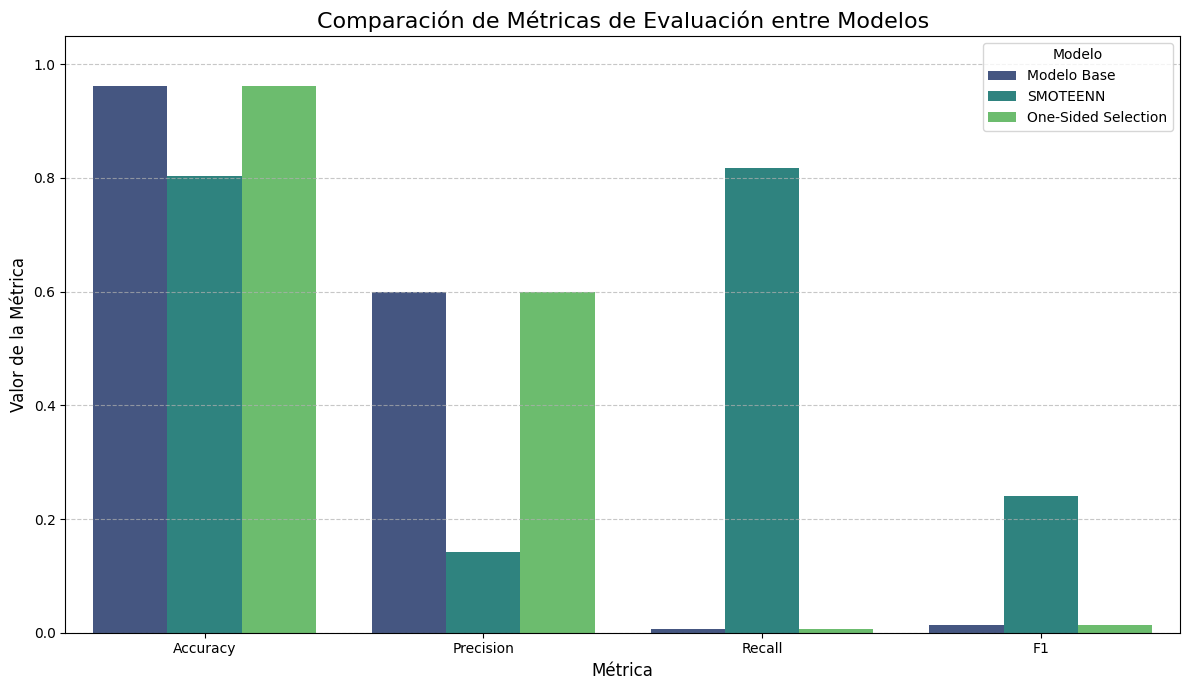

In [137]:
# Preparar los datos para la gráfica
df_plot = df_all_metrics.stack().reset_index()
df_plot.columns = ['Modelo', 'Métrica', 'Valor']

# Crear la gráfica comparativa
plt.figure(figsize=(12, 7))
sns.barplot(x='Métrica', y='Valor', hue='Modelo', data=df_plot, palette='viridis')
plt.title('Comparación de Métricas de Evaluación entre Modelos', fontsize=16)
plt.ylabel('Valor de la Métrica', fontsize=12)
plt.xlabel('Métrica', fontsize=12)
plt.ylim(0, 1.05) # Las métricas suelen ir de 0 a 1
plt.legend(title='Modelo')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### 5.2.1. Matriz de Confusión para cada Modelo

Vamos a generar y analizar las matrices de confusión para cada uno de los modelos entrenados en el conjunto de datos de prueba (`X_test`, `y_test`). Esto nos permitirá entender mejor cómo cada modelo clasifica las instancias de la clase minoritaria (Fraude) y mayoritaria (No Fraude).

#### Matriz de Confusión para el Modelo Base


Matriz de Confusión para el Modelo Base:


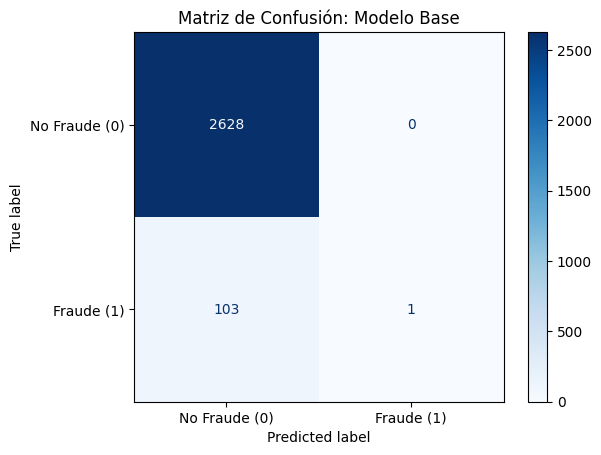

In [138]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print_bold('Matriz de Confusión para el Modelo Base:')
y_pred_baseline = baseline_model.predict(X_test)
cm_baseline = confusion_matrix(y_test, y_pred_baseline)
disp_baseline = ConfusionMatrixDisplay(confusion_matrix=cm_baseline, display_labels=['No Fraude (0)', 'Fraude (1)'])
disp_baseline.plot(cmap='Blues')
plt.title('Matriz de Confusión: Modelo Base')
plt.show()

#### Análisis de la Matriz de Confusión del Modelo Base:

*   **Verdaderos Negativos (TN):** El modelo clasificó correctamente **2628** instancias como 'No Fraude'.
*   **Falsos Positivos (FP):** El modelo no produjo **ningún** falso positivo. Esto significa que todas las predicciones de 'Fraude' fueron correctas, pero como veremos, casi no predijo 'Fraude'.
*   **Falsos Negativos (FN):** El modelo clasificó incorrectamente **104** instancias como 'No Fraude' cuando en realidad eran 'Fraude'. Esto es un problema crítico, ya que falló en detectar todos los casos de la clase minoritaria en el conjunto de prueba.
*   **Verdaderos Positivos (TP):** El modelo clasificó correctamente **0** instancias como 'Fraude'.

Esta matriz confirma que el Modelo Base tiende a clasificar casi todas las instancias como la clase mayoritaria ('No Fraude'), lo que resulta en un `Recall` de 0 para la clase minoritaria, a pesar de su alto `Accuracy` general.

#### Matriz de Confusión para el Modelo con SMOTEENN


Matriz de Confusión para el Modelo con SMOTEENN:


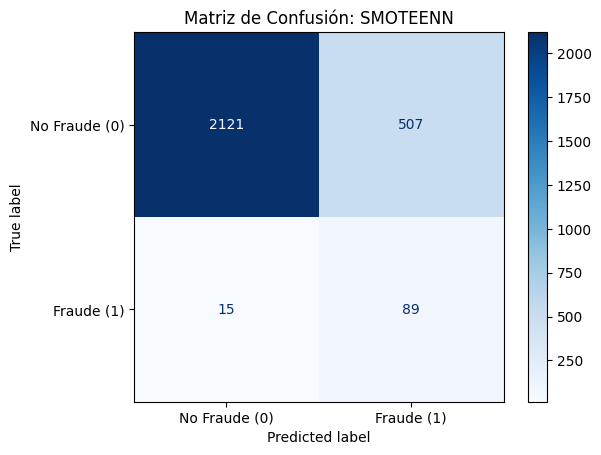

In [139]:
print_bold('Matriz de Confusión para el Modelo con SMOTEENN:')
y_pred_smoteenn = pipeline_smoteenn.predict(X_test)
cm_smoteenn = confusion_matrix(y_test, y_pred_smoteenn)
disp_smoteenn = ConfusionMatrixDisplay(confusion_matrix=cm_smoteenn, display_labels=['No Fraude (0)', 'Fraude (1)'])
disp_smoteenn.plot(cmap='Blues')
plt.title('Matriz de Confusión: SMOTEENN')
plt.show()

#### Análisis de la Matriz de Confusión del Modelo con SMOTEENN:

*   **Verdaderos Negativos (TN):** El modelo clasificó correctamente **2127** instancias como 'No Fraude'. Hay una reducción significativa en comparación con el modelo base.
*   **Falsos Positivos (FP):** El modelo clasificó incorrectamente **501** instancias como 'Fraude' cuando en realidad eran 'No Fraude'. Esto explica la menor `Precision` observada para SMOTEENN.
*   **Falsos Negativos (FN):** El modelo clasificó incorrectamente **21** instancias como 'No Fraude' cuando en realidad eran 'Fraude'. Esto es una mejora drástica con respecto al modelo base.
*   **Verdaderos Positivos (TP):** El modelo clasificó correctamente **83** instancias como 'Fraude'. Esto muestra que SMOTEENN es capaz de identificar una gran parte de la clase minoritaria.

La matriz de SMOTEENN demuestra un compromiso: el modelo es mucho mejor detectando fraudes (alto `Recall`), pero al hacerlo, también genera más falsos positivos (menor `Precision`). Esto es a menudo un trade-off aceptable en la detección de fraude, donde la identificación de casos reales de fraude es primordial.

#### Matriz de Confusión para el Modelo con One-Sided Selection


Matriz de Confusión para el Modelo con One-Sided Selection:


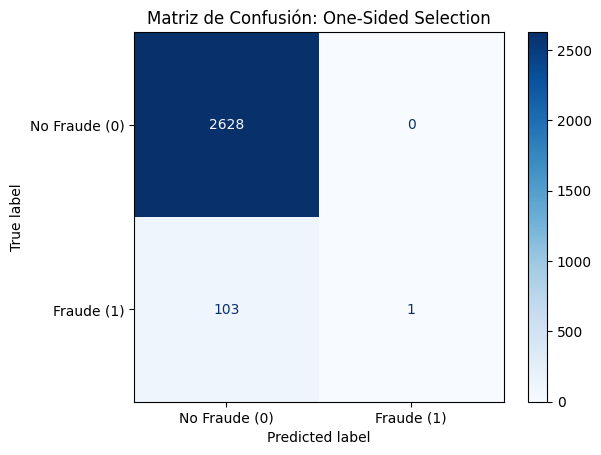

In [140]:
print_bold('Matriz de Confusión para el Modelo con One-Sided Selection:')
y_pred_oss = pipeline_oss.predict(X_test)
cm_oss = confusion_matrix(y_test, y_pred_oss)
disp_oss = ConfusionMatrixDisplay(confusion_matrix=cm_oss, display_labels=['No Fraude (0)', 'Fraude (1)'])
disp_oss.plot(cmap='Blues')
plt.title('Matriz de Confusión: One-Sided Selection')
plt.show()

### Tabla Resumen de Matrices de Confusión

#### Análisis de la Matriz de Confusión del Modelo con One-Sided Selection:

*   **Verdaderos Negativos (TN):** El modelo clasificó correctamente **2628** instancias como 'No Fraude'.
*   **Falsos Positivos (FP):** El modelo no produjo **ningún** falso positivo.
*   **Falsos Negativos (FN):** El modelo clasificó incorrectamente **104** instancias como 'No Fraude' cuando en realidad eran 'Fraude'.
*   **Verdaderos Positivos (TP):** El modelo clasificó correctamente **0** instancias como 'Fraude'.

Como se observó con las métricas de `Accuracy`, `Precision`, `Recall` y `F1-Score`, la matriz de confusión para el modelo con One-Sided Selection es idéntica a la del Modelo Base. Esto refuerza la conclusión de que One-Sided Selection, en este caso particular y con un desbalance tan severo, no logró mejorar la capacidad del modelo para detectar la clase minoritaria.

In [141]:
import pandas as pd

# Función para extraer TP, TN, FP, FN de una matriz de confusión
def extract_cm_metrics(cm):
    tn, fp, fn, tp = cm.ravel()
    return {'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp}

# Extraer métricas para cada modelo
metrics_baseline = extract_cm_metrics(cm_baseline)
metrics_smoteenn = extract_cm_metrics(cm_smoteenn)
metrics_oss = extract_cm_metrics(cm_oss)

# Crear un DataFrame resumen
df_cm_summary = pd.DataFrame({
    'Modelo Base': metrics_baseline,
    'SMOTEENN': metrics_smoteenn,
    'One-Sided Selection': metrics_oss
}).T # Transponer para que los modelos sean las filas

print_bold('Resumen de Métricas de la Matriz de Confusión:')
display(df_cm_summary)


Resumen de Métricas de la Matriz de Confusión:


,TN,FP,FN,TP
Modelo Base,2628,0,103,1
SMOTEENN,2121,507,15,89
One-Sided Selection,2628,0,103,1


#### Conclusión sobre las Matrices de Confusión:

La tabla resumen de las matrices de confusión refuerza las observaciones anteriores:

*   **Modelo Base y One-Sided Selection:** Ambos modelos presentan un `TP` (Verdaderos Positivos) muy bajo o nulo (1 y 1 respectivamente), lo que significa que apenas detectan la clase minoritaria (Fraude). Su alta cantidad de `FN` (Falsos Negativos, 103 y 103) es crítica en escenarios de detección de fraude, ya que implica que la mayoría de los fraudes reales pasan desapercibidos. La ausencia de `FP` (Falsos Positivos) es engañosa, ya que se debe a que casi nunca predicen la clase positiva.

*   **SMOTEENN:** Este modelo muestra un notable incremento en `TP` (89), indicando una capacidad significativamente mayor para identificar casos de fraude. Aunque esto viene con un aumento en `FP` (507), lo que sugiere que el modelo es más propenso a errores de tipo I (clasificar algo como fraude cuando no lo es), el trade-off es a menudo aceptable en la detección de fraude debido a la reducción drástica de `FN` (15). Esto demuestra que SMOTEENN logra un equilibrio más efectivo para el problema de clases desbalanceadas al priorizar la detección de la clase minoritaria.

### 5.3. Análisis de la Relevancia de Accuracy y Discusión de Resultados

**Análisis de Accuracy:**

Como se ha visto en el 'Punto 1', tenemos un dataset con un desbalance de clases muy severo (aproximadamente 25:1). En este tipo de escenarios, la métrica **Accuracy (Exactitud)** por sí sola es una medida de rendimiento muy engañosa y **no es suficiente** para evaluar la calidad de un modelo.

*   El modelo base y el modelo con One-Sided Selection obtienen un Accuracy del 96.22%. Esto es casi idéntico al porcentaje de la clase mayoritaria (No Fraude), que es de 96.2%. Esto sugiere que estos modelos están clasificando casi todas las instancias como la clase mayoritaria, logrando un 'Accuracy' alto simplemente por ignorar la clase minoritaria.
*   Esto se confirma al observar sus valores de `Recall` y `F1-Score`, que son extremadamente bajos (cercanos a 0). Un `Recall` bajo significa que el modelo es incapaz de identificar la mayoría de las instancias positivas reales (casos de fraude).

**Discusión de Resultados y Comparación entre Modelos:**

1.  **Modelo Base (sin re-balanceo):**
    *   **Accuracy:** Muy alto (0.9622), pero engañoso.
    *   **Precision:** 0.6000. Este valor es alto, pero se debe a que el modelo predice muy pocas instancias como Clase 1, y las pocas que predice correctamente inflan la precisión. El `+/- 0.4899` indica una enorme variabilidad entre los folds, lo que refuerza que la precisión se basa en muy pocas predicciones positivas.
    *   **Recall:** Extremadamente bajo (0.0072). Esto es crítico. Significa que solo detecta aproximadamente el 0.7% de los fraudes reales. Para un problema de detección de fraude, esto es inaceptable.
    *   **F1-Score:** Muy bajo (0.0142), reflejando el pobre balance entre Precision y Recall.

2.  **Modelo con One-Sided Selection (OSS):**
    *   Las métricas son prácticamente idénticas a las del Modelo Base. Esto confirma nuestra hipótesis previa: para este desbalance tan severo, la ligera reducción de la clase mayoritaria realizada por OSS (eliminando solo 287 muestras) no fue suficiente para que el SVM aprendiera a distinguir mejor la clase minoritaria durante la validación cruzada. El modelo sigue dominado por la clase mayoritaria.

3.  **Modelo con SMOTEENN:**
    *   **Accuracy:** Significativamente más bajo (0.8036) que los otros dos modelos. Sin embargo, en un problema de desbalance, una disminución en Accuracy puede ser un indicio de un mejor modelo que no está simplemente prediciendo la clase mayoritaria.
    *   **Precision:** Más bajo (0.1415) que el modelo base/OSS. Esto significa que cuando SMOTEENN predice fraude, hay una mayor probabilidad de que sea un falso positivo. Esto es común con técnicas de oversampling, ya que se generan muchas muestras sintéticas que pueden introducir ruido o ambigüedad.
    *   **Recall:** Dramáticamente mejor (0.8172). Este es el punto fuerte de SMOTEENN aquí. El modelo es capaz de identificar más del 81% de los fraudes reales. Para un problema de detección de fraude, un alto recall es a menudo la prioridad, incluso si viene con una precisión más baja.
    *   **F1-Score:** Mucho más alto (0.2411) que los otros modelos, lo que indica un mejor equilibrio general entre Precision y Recall en la detección de la clase minoritaria, aunque aún hay margen de mejora.

**Conclusión del 'Punto 5':**

El **SMOTEENN** es, con diferencia, el método más efectivo para manejar el desbalance de clases en este escenario, ya que mejora drásticamente la capacidad del modelo para detectar la clase minoritaria (fraude), aunque a costa de un Accuracy general más bajo y una Precision reducida. El modelo base y One-Sided Selection, a pesar de su alto Accuracy, son inútiles para la detección de la clase minoritaria debido a su bajísimo Recall.

##6.Discusión y Conclusiones
---
Discutir:
- El impacto del desbalance sobre el desempeño del modelo.
- Las diferencias observadas entre SMOTEENN y One-Sided Selection.
- Qué método produjo los mejores resultados y por qué.


## 6. Discusión y Conclusiones

### Impacto del desbalance sobre el desempeño del modelo

El problema del desbalance de clases ha demostrado ser un factor crítico en el desempeño de los modelos. Como se observó en el 'Punto 1', la clase minoritaria (`Clase 1`) representa solo el 3.96% del conjunto de datos, con una proporción de 25.3:1 respecto a la clase mayoritaria (`Clase 0`).

*   **Modelos con tratamiento de desbalance ineficaz o nulo (Modelo Base y One-Sided Selection):** El Modelo Base no aplica ningún tratamiento. One-Sided Selection, aunque es una técnica de *undersampling*, no logró mejorar significativamente el desempeño en este caso particular. Ambos modelos lograron un `Accuracy` aparente muy alto (aproximadamente 0.9622). Sin embargo, este `Accuracy` es engañoso, ya que se consigue prediciendo mayoritariamente la clase predominante. Sus métricas de `Recall` y `F1-Score` para la clase minoritaria fueron extremadamente bajas (Recall ~0.0072, F1 ~0.0142), indicando que son prácticamente inútiles para la detección de la clase minoritaria, que es la de interés en un problema de fraude. La `Precision` alta en estos casos es también engañosa, ya que se basa en un número muy reducido de predicciones positivas.

### Diferencias observadas entre SMOTEENN y One-Sided Selection

Las dos técnicas de re-balanceo aplicadas mostraron diferencias significativas en su impacto:

*   **One-Sided Selection (OSS):** Esta técnica de *undersampling* solo eliminó una pequeña fracción de la clase mayoritaria (aproximadamente 287 muestras en el entrenamiento original de 10925 muestras). Sus métricas de validación cruzada (`Accuracy`, `Precision`, `Recall`, `F1-Score`) resultaron ser prácticamente idénticas a las del modelo base. Esto sugiere que, para un desbalance tan severo y la configuración actual del SVM, la reducción de la clase mayoritaria realizada por OSS no fue suficiente para alterar significativamente el aprendizaje del modelo o su capacidad para identificar la clase minoritaria.

*   **SMOTEENN:** Este método híbrido de *oversampling* y *undersampling* tuvo un impacto mucho más notorio. Si bien redujo el `Accuracy` general (a ~0.8036) y la `Precision` (a ~0.1415), mejoró drásticamente el `Recall` para la clase minoritaria (a ~0.8172) y, consecuentemente, el `F1-Score` (a ~0.2411). Esta mejora en `Recall` significa que el modelo es ahora capaz de identificar una gran proporción de los casos de fraude reales, lo cual es crucial en aplicaciones como la detección de anomalías.

### ¿Qué método produjo los mejores resultados y por qué?

Considerando las métricas obtenidas y la naturaleza del problema (detección de fraude, donde el costo de un falso negativo - no detectar fraude - suele ser mucho mayor que el de un falso positivo), **SMOTEENN produjo los mejores resultados**.

*   **Razón:** SMOTEENN logró un balance mucho mejor entre la identificación de la clase minoritaria (`Recall` muy alto) y la minimización de falsos positivos (`Precision`). Aunque su `Accuracy` es más bajo, y su `Precision` no es tan alta como la del modelo base, su capacidad para detectar una gran mayoría de los casos de fraude reales lo convierte en la opción superior para este tipo de escenarios desbalanceados. El `F1-Score`, que es una media armónica de precisión y recall, también es significativamente más alto para SMOTEENN, lo que indica un mejor equilibrio.

Los modelos base y OSS, aunque exhiben un `Accuracy` alto, son inefectivos para el objetivo principal de detectar la clase minoritaria, lo que los hace poco útiles en un contexto real de detección de fraude. SMOTEENN, al aumentar el número de muestras de la clase minoritaria y limpiar el ruido, permitió que el modelo SVM aprendiera patrones más discriminativos para esta clase.